# Morfología matemática para limpieza de máscaras

En este cuaderno vas a usar operaciones morfológicas para limpiar máscaras binarias. La idea central es entender qué pasa cuando expandís, reducís, abrís o cerrás regiones de una imagen binaria.


## Objetivo

Comprender cómo las operaciones morfológicas modifican la forma de una máscara y por qué conviene elegir una u otra según el tipo de defecto que querés corregir.

## Resultados de aprendizaje

Al finalizar este cuaderno, vas a poder:

- distinguir erosión y dilatación;
- explicar qué problema intenta resolver la apertura y qué problema intenta resolver la clausura;
- limpiar una máscara sintética y otra obtenida de una imagen real;
- describir el efecto del tamaño del kernel sobre el resultado.

## Relación con la secuencia

Este cuaderno continúa el trabajo con máscaras y prepara el terreno para contornos y mediciones geométricas. Si la máscara está mal, casi todo lo que sigue también queda mal.


## Módulos que vamos a usar

- `cv2`: para aplicar operaciones morfológicas y umbralizar imágenes.
- `numpy`: para construir una máscara sintética y definir kernels.
- `matplotlib.pyplot`: para comparar resultados.
- `pathlib.Path`: para leer una imagen real.


In [1]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt


## 1. Empezar con una máscara controlada

Primero conviene trabajar sobre una máscara sintética. Así podemos ver con claridad qué cambia en la forma sin que aparezcan otros problemas de segmentación mezclados.


In [2]:
mascara_base = np.zeros((260, 420), dtype=np.uint8)
cv2.rectangle(mascara_base, (40, 60), (170, 190), 255, -1)
cv2.circle(mascara_base, (290, 130), 55, 255, -1)

mascara_ruidosa = mascara_base.copy()
np.random.seed(7)

for _ in range(400):
    fila = np.random.randint(0, mascara_ruidosa.shape[0])
    columna = np.random.randint(0, mascara_ruidosa.shape[1])
    mascara_ruidosa[fila, columna] = 255

cv2.circle(mascara_ruidosa, (110, 130), 18, 0, -1)
cv2.circle(mascara_ruidosa, (290, 130), 10, 0, -1)


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(260, 420), dtype=uint8)

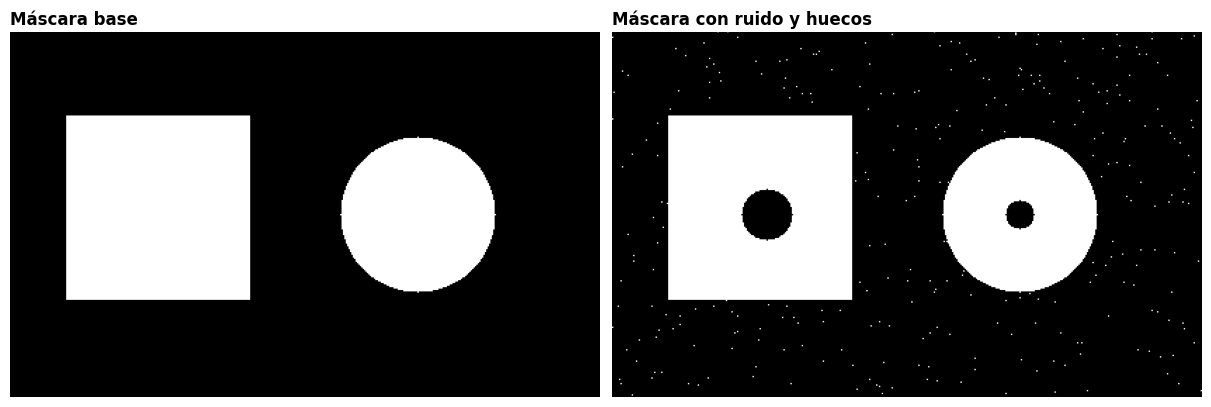

In [3]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
ejes[0].imshow(mascara_base, cmap="gray")
ejes[0].set_title("Máscara base", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(mascara_ruidosa, cmap="gray")
ejes[1].set_title("Máscara con ruido y huecos", fontweight="bold", loc="left")
ejes[1].axis("off")
plt.show()


## 2. Erosión y dilatación

La erosión tiende a reducir regiones blancas. La dilatación tiende a expandirlas. Mirarlas por separado ayuda a entender qué hacen antes de combinarlas.


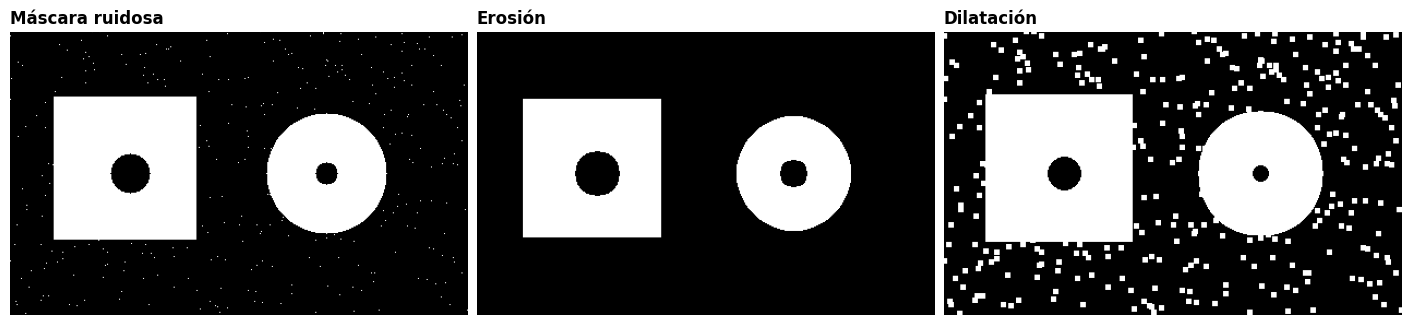

In [4]:
kernel = np.ones((5, 5), dtype=np.uint8)
mascara_erosion = cv2.erode(mascara_ruidosa, kernel, iterations=1)
mascara_dilatacion = cv2.dilate(mascara_ruidosa, kernel, iterations=1)

fig, ejes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
ejes[0].imshow(mascara_ruidosa, cmap="gray")
ejes[0].set_title("Máscara ruidosa", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(mascara_erosion, cmap="gray")
ejes[1].set_title("Erosión", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(mascara_dilatacion, cmap="gray")
ejes[2].set_title("Dilatación", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()


## 3. Apertura y clausura

La apertura suele servir para eliminar ruido pequeño. La clausura suele servir para cerrar huecos o unir regiones cercanas. Ahora vamos a ver ambas sobre la misma máscara.


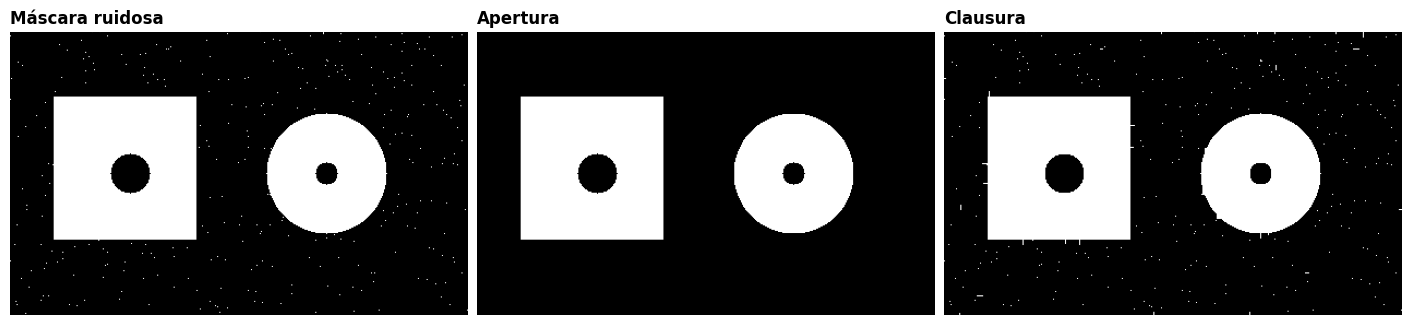

In [5]:
mascara_apertura = cv2.morphologyEx(mascara_ruidosa, cv2.MORPH_OPEN, kernel, iterations=1)
mascara_clausura = cv2.morphologyEx(mascara_ruidosa, cv2.MORPH_CLOSE, kernel, iterations=1)

fig, ejes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
ejes[0].imshow(mascara_ruidosa, cmap="gray")
ejes[0].set_title("Máscara ruidosa", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(mascara_apertura, cmap="gray")
ejes[1].set_title("Apertura", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(mascara_clausura, cmap="gray")
ejes[2].set_title("Clausura", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()


Compará qué problema resuelve mejor cada operación. Si querés sacar puntitos aislados, apertura suele ser una mejor candidata. Si querés cerrar agujeros o unir partes cercanas, clausura suele ser más útil.


## 4. Transferir la idea a una imagen real

Ahora vamos a tomar una imagen con notas manuscritas, binarizarla y aplicar una clausura simple para reforzar trazos cortados.


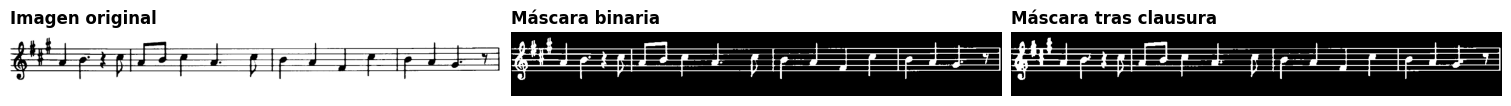

In [6]:
ruta_notas = Path("Imagenes") / "notes.png"
imagen_notas_gris = cv2.imread(str(ruta_notas), cv2.IMREAD_GRAYSCALE)
if imagen_notas_gris is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_notas}")

_, mascara_texto = cv2.threshold(imagen_notas_gris, 180, 255, cv2.THRESH_BINARY_INV)
mascara_texto_limpia = cv2.morphologyEx(mascara_texto, cv2.MORPH_CLOSE, np.ones((3, 3), dtype=np.uint8), iterations=1)

fig, ejes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
ejes[0].imshow(imagen_notas_gris, cmap="gray")
ejes[0].set_title("Imagen original", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(mascara_texto, cmap="gray")
ejes[1].set_title("Máscara binaria", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(mascara_texto_limpia, cmap="gray")
ejes[2].set_title("Máscara tras clausura", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()


## Actividad breve

Probá cambiar el tamaño del kernel en la apertura o en la clausura. Después respondé:

1. ¿qué mejora produce el cambio?
2. ¿qué deformación introduce?
3. ¿cómo decidirías el tamaño del kernel en un caso real?


## Cierre

Las operaciones morfológicas no “limpian” imágenes en abstracto: modifican formas binarias con un criterio geométrico. Por eso conviene pensarlas siempre en relación con el defecto que querés corregir y con la tarea que viene después.
